<a href="https://colab.research.google.com/github/Satwikagv/EE1030/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# k-Nearest Neighbors: From Scratch, Explored End-to-End

This notebook implements a k-Nearest Neighbors (KNN) classifier from scratch (no `sklearn` for the model itself) and uses it to study how the algorithm actually behaves, rather than just how to call it.

**What's inside:**
- A synthetic 2-class dataset built from four bivariate Gaussians, used as a controlled sandbox for visualizing decision boundaries.
- A `KNeighborsClassifier` implemented with both L1 and L2 distance metrics.
- Hold-out cross-validation to pick a good value of `k`, plus a look at how the choice of `k` trades off bias and variance.
- Experiments on how training set size and the underlying data distribution (Gaussian vs. Laplacian) affect performance.
- A comparison of L1 vs. L2 distance and how each shapes the decision regions.
- A final application to MNIST digit classification, including model selection over `k` and distance metric, and a confusion matrix to see which digits get confused with each other.

The goal throughout is to build intuition for *why* KNN behaves the way it does under different settings, not just to report accuracy numbers.


## Setup and Approach

**Synthetic data.** I generate four bivariate Gaussians centered at (0,0), (0,1), (1,0), and (1,1), each with a diagonal covariance (variance 0.1 on each axis). I sample 90 points per Gaussian (360 total), and use 30 per Gaussian for training and 60 per Gaussian for testing (120 train / 240 test overall). Clusters at (0,0) and (1,1) are labeled class +1; clusters at (0,1) and (1,0) are labeled class -1 — this gives an XOR-like layout that's a nice stress test for a local classifier like KNN. I visualize both the training and test splits before doing anything else.

**Building the classifier.** I implement a `KNeighbourClassifier` class with `fit()` and `predict()` methods that support both `k` and the distance metric (L1 or L2) as hyperparameters. I train it, evaluate test accuracy, plot which test points get misclassified, and visualize the resulting decision boundary over a 2D grid.

**Choosing k.** Rather than picking `k` arbitrarily, I use hold-out cross-validation: set aside a fraction ρ of the training data for validation, repeat this several times with different random splits, and track training/validation error across a range of odd `k` values (to avoid ties). The `k` with the lowest average validation error is the one I carry forward.

**Robustness checks.** I then look at how performance changes as the training set grows, and whether the choice between a Gaussian and a Laplacian data-generating distribution (and between L1 and L2 distance) matters for classification error.

**Distance metric and decision regions.** I compare L1 vs. L2 distance directly by plotting their decision regions side by side.

**MNIST.** Finally, I apply the same KNN implementation (extended to multi-class voting) to MNIST digit classification: a train/validation/test split, a small grid search over `k` and distance metric using the validation set, and a confusion matrix on the test set to see which digits are hardest to tell apart.


In [ ]:
#All imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import random
import math
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

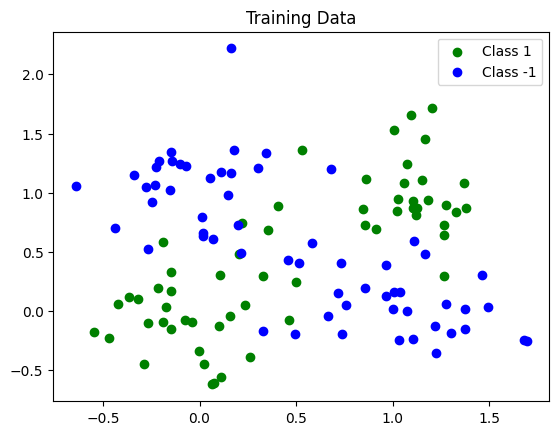

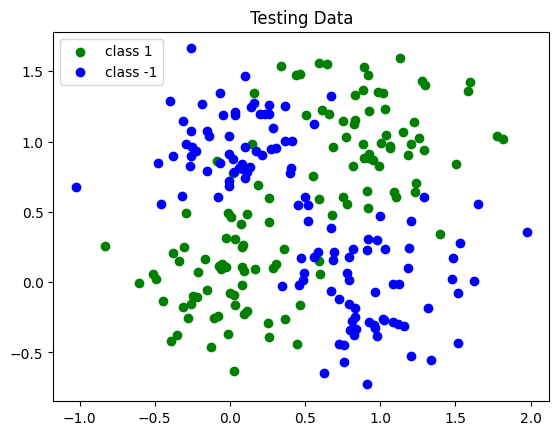

In [ ]:
########################################
#Part(a) #Synthetic data generation
########################################
np.random.seed(42)  # for reproducibility
#Define means and covariances
mean1=[0,0]
mean2=[0,1]
mean3=[1,0]
mean4=[1,1]
cov=[[0.1,0],
     [0,0.1]]

#Sample data points from the bivariate Gaussian distribution
data = []

samples = np.random.multivariate_normal(mean1,cov,90)
data.append(samples)
samples = np.random.multivariate_normal(mean2,cov,90)
data.append(samples)
samples = np.random.multivariate_normal(mean3,cov,90)
data.append(samples)
samples = np.random.multivariate_normal(mean4,cov,90)
data.append(samples)


#Generate training data
#Generate testing data

X_train = []
y_train = []
X_test = []
y_test = []

for i in range(4):
  train_samples = data[i][:30]
  test_samples = data[i][30:]

  if i==0 or i==3:
    label= 1
  else:
    label = -1

  for sample in train_samples:
    X_train.append(sample)
    y_train.append(label)


  for sample in test_samples:
    X_test.append(sample)
    y_test.append(
        label)



X_train = np.vstack(X_train)
Y_train = np.hstack(y_train)

X_test = np.vstack(X_test)
Y_test = np.hstack(y_test)

#Visualize the data using plt.scatter() function

plt.figure()
plt.scatter(X_train[Y_train==1][:,0],
            X_train[Y_train==1][:,1],
            color='green',
            label='Class 1')

plt.scatter(X_train[Y_train==-1][:,0],
            X_train[Y_train==-1][:,1],
            color='blue',
            label='Class -1')

plt.title("Training Data")
plt.legend()
plt.show()

plt.figure()
plt.scatter(X_test[Y_test==1][:,0],
            X_test[Y_test==1][:,1],
            color='green',
            label='class 1')
plt.scatter(X_test[Y_test==-1][:,0],
            X_test[Y_test==-1][:,1],
            color='blue',
            label='class -1')
plt.title("Testing Data")
plt.legend()
plt.show()


k = 1, distance = l1
Accuracy: 0.825
Correct: 198
Misclassified: 42


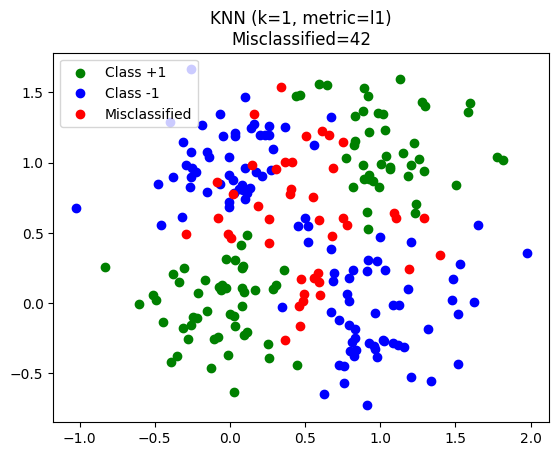

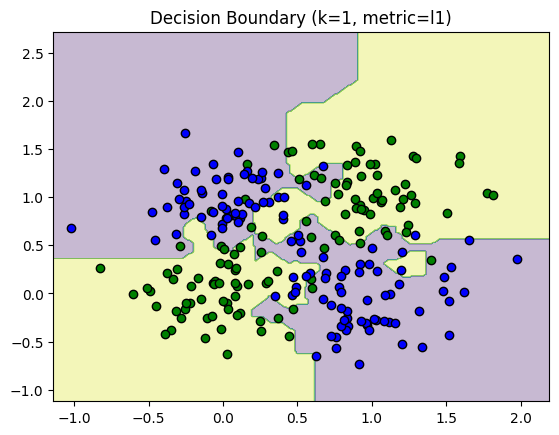

k = 1, distance = l2
Accuracy: 0.8208333333333333
Correct: 197
Misclassified: 43


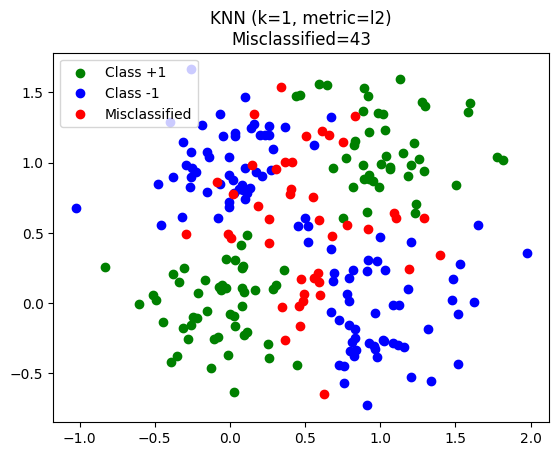

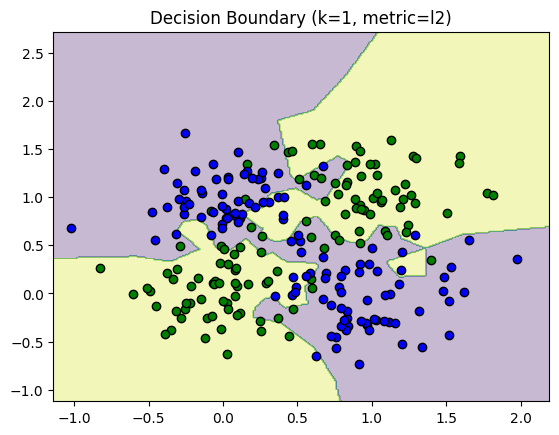

k = 5, distance = l1
Accuracy: 0.8541666666666666
Correct: 205
Misclassified: 35


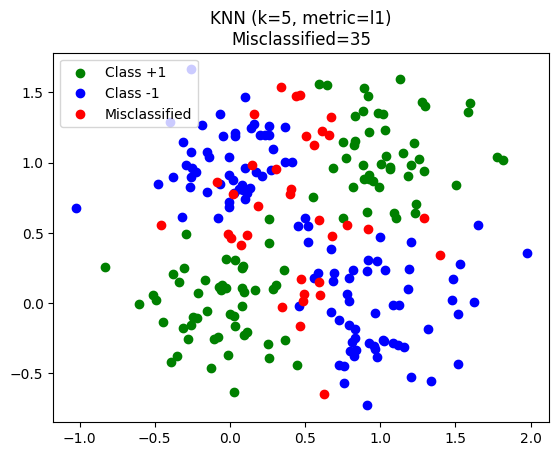

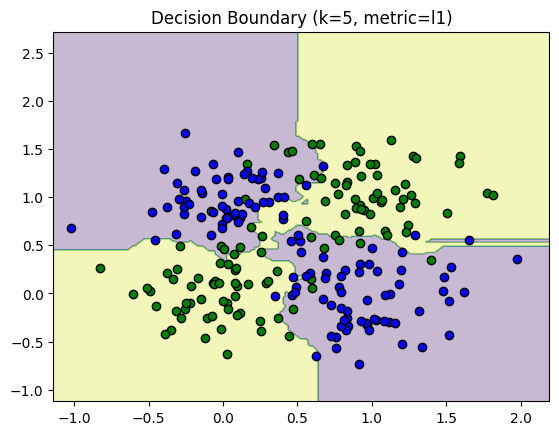

k = 5, distance = l2
Accuracy: 0.8708333333333333
Correct: 209
Misclassified: 31


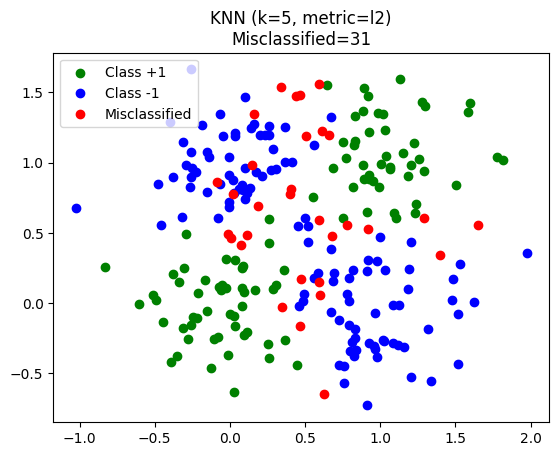

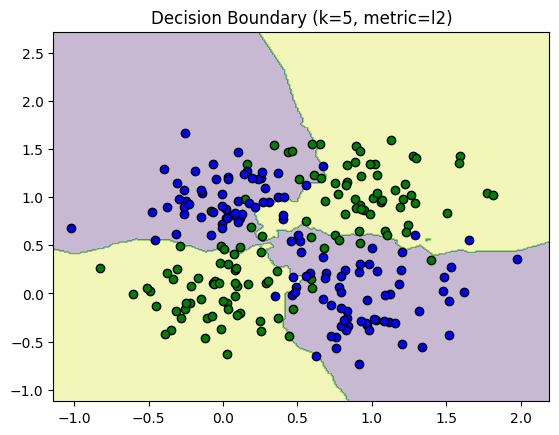

k = 10, distance = l1
Accuracy: 0.8833333333333333
Correct: 212
Misclassified: 28


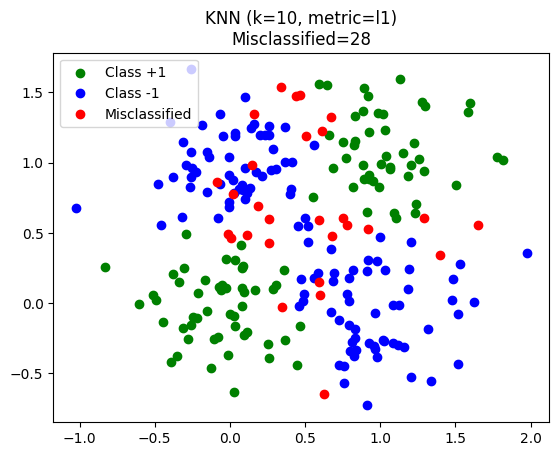

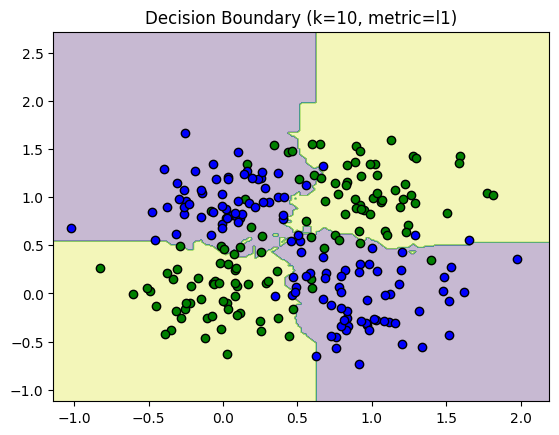

k = 10, distance = l2
Accuracy: 0.8833333333333333
Correct: 212
Misclassified: 28


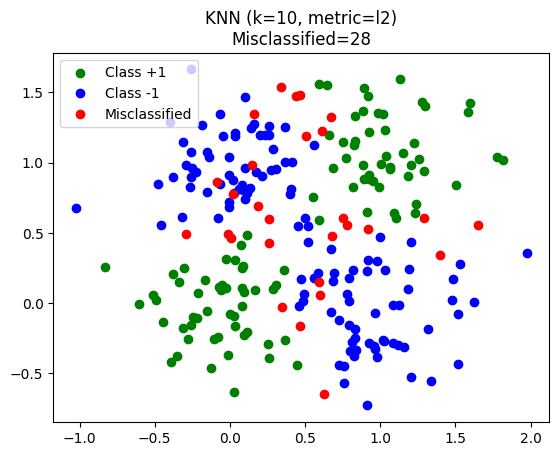

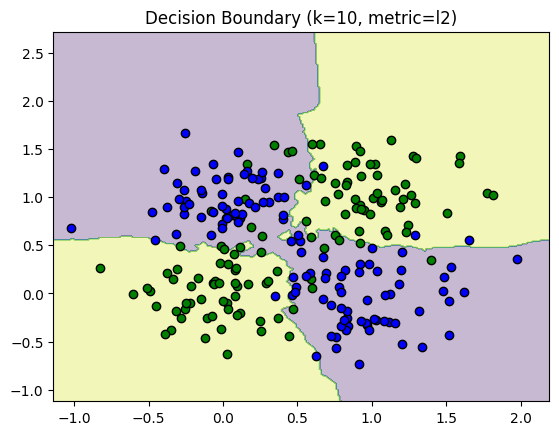

In [ ]:
########################################
#Part(b) #KNN classification
########################################

class KNeighborsClassifier:
    """
    K-Nearest Neighbors Classifier
    """
    def __init__(self, n_neighbors=5,distance_metric="l2"):
        self.n_neighbors = n_neighbors
        self.distance_metric = distance_metric
        self.X_train = None
        self.y_train = None

    def fit(self,X_train,Y_train):
        self.X_train = X_train
        self.y_train = Y_train

    def predict(self,X_test):
        predictions = []

        for tp in X_test:
            if self.distance_metric == "l2":
              distances = np.linalg.norm(self.X_train - tp, axis=1)
            if self.distance_metric == "l1":
              distances = np.sum(np.abs(self.X_train - tp), axis=1)
            k_indices = np.argsort(distances)[:self.n_neighbors]
            k_labels = self.y_train[k_indices]

            # Tie-breaker: np.sign(0) == 0, which is not a valid class label.
            # This happens on exact ties (e.g. k=10, 5 vs 5 votes). Default to
            # the label of the single closest neighbor in that case.
            vote_sum = np.sum(k_labels)
            prediction = k_labels[0] if vote_sum == 0 else np.sign(vote_sum)
            predictions.append(prediction)

        return np.array(predictions)


def KNNAccuracy(true,pred):
    return np.mean(true==pred)

k_values = [1, 5, 10]
distance_metrics = ["l1", "l2"]

for k in k_values:
    for metric in distance_metrics:

        print(f"k = {k}, distance = {metric}")

        knn = KNeighborsClassifier(n_neighbors=k,distance_metric=metric)
        knn.fit(X_train, Y_train)
        Y_pred = knn.predict(X_test)
        accuracy = KNNAccuracy(Y_test, Y_pred)

        total_points = len(Y_test)
        correct = np.sum(Y_test == Y_pred)
        misclassified = np.sum(Y_test != Y_pred)

        print("Accuracy:", accuracy)
        print("Correct:", correct)
        print("Misclassified:", misclassified)

        plt.figure()

        plt.scatter(X_test[(Y_test==1) & (Y_pred==1),0],
                    X_test[(Y_test==1) & (Y_pred==1),1],
                    color='green', label='Class +1')

        plt.scatter(X_test[(Y_test==-1) & (Y_pred==-1),0],
                    X_test[(Y_test==-1) & (Y_pred==-1),1],
                    color='blue', label='Class -1')

        plt.scatter(X_test[Y_test!=Y_pred,0],
                    X_test[Y_test!=Y_pred,1],
                    color='red', label='Misclassified')

        plt.title(f"KNN (k={k}, metric={metric})\n"
                  f"Misclassified={misclassified}")

        plt.legend()
        plt.show()

        x_min, x_max = X_train[:,0].min()-0.5, X_train[:,0].max()+0.5
        y_min, y_max = X_train[:,1].min()-0.5, X_train[:,1].max()+0.5

        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, 300),
            np.linspace(y_min, y_max, 300)
        )

        grid_points = np.c_[xx.ravel(), yy.ravel()]

        Z = knn.predict(grid_points)
        Z = Z.reshape(xx.shape)

        plt.figure()
        plt.contourf(xx, yy, Z, alpha=0.3)

        plt.scatter(X_test[Y_test==1][:,0],
                    X_test[Y_test==1][:,1],
                    color='green', edgecolor='k')

        plt.scatter(X_test[Y_test==-1][:,0],
                    X_test[Y_test==-1][:,1],
                    color='blue', edgecolor='k')

        plt.title(f"Decision Boundary (k={k}, metric={metric})")
        plt.show()


**Observations — effect of k and distance metric on the base classifier**

**Effect of $k$**

For $k=1$:
*   The decision boundary is irregular and flexible.
*   Because of the small $k$ value the bias is low but the variance is high due to overfitting.
*   The accuracy is comparatively low.

For $k=5$:
*   The decision boundary is smoother than for $k=1$.
*   This setting is the most accurate of the three.

For $k=10$:
*   The decision boundary is even smoother.
*   Accuracy is slightly lower than for $k=5$.
*   This has higher bias and lower variance than $k=1$, reflecting mild underfitting.

---

**Effect of distance metric**

L1 distance:
*   Produces sharper boundaries.
*   Slightly alters the shape of the decision regions.

L2 distance:
*   Produces smoother boundaries.
*   Forms circular neighborhoods around data points.

The decision boundaries are slightly different for L1 and L2 distances, though the overall trend with $k$ dominates.


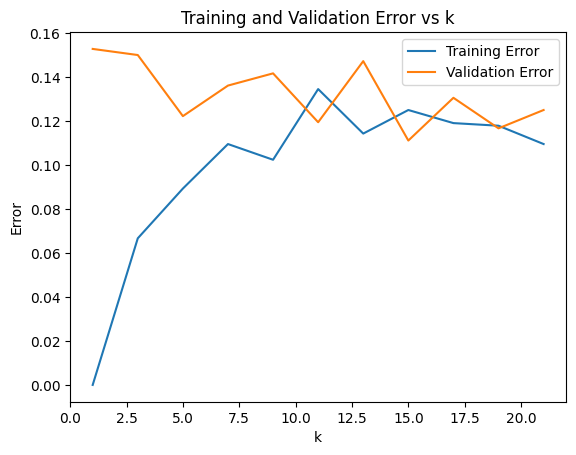

Best k based on validation error: 15
Test error with best k: 0.12083333333333335
Test accuracy with best k: 0.8791666666666667


In [ ]:
####################################
#Part(c): Parameter selection: What is good value for k?
####################################
np.random.seed(1)  # for reproducible cross-validation results

def holdoutCVkNN(k_range, rho, repetitions=10):

    train_errors = []
    val_errors = []

    n = len(X_train)
    val_size = int(rho * n)

    for k in k_range:

        train_error_k = []
        val_error_k = []

        for _ in range(repetitions):

            indices = np.random.permutation(n)

            val_indices = indices[:val_size]
            train_indices = indices[val_size:]

            X_tr = X_train[train_indices]
            y_tr = Y_train[train_indices]

            X_val = X_train[val_indices]
            y_val = Y_train[val_indices]

            model = KNeighborsClassifier(n_neighbors=k, distance_metric="l2")
            model.fit(X_tr, y_tr)

            y_tr_pred = model.predict(X_tr)
            train_error = 1 - KNNAccuracy(y_tr, y_tr_pred)
            train_error_k.append(train_error)

            y_val_pred = model.predict(X_val)
            val_error = 1 - KNNAccuracy(y_val, y_val_pred)
            val_error_k.append(val_error)

        train_errors.append(np.mean(train_error_k))
        val_errors.append(np.mean(val_error_k))

    return train_errors, val_errors

k_range = list(range(1, 22, 2))   # odd k values
rho = 0.3

train_errors, val_errors = holdoutCVkNN(k_range, rho)

plt.figure()
plt.plot(k_range, train_errors)
plt.plot(k_range, val_errors)
plt.xlabel("k")
plt.ylabel("Error")
plt.title("Training and Validation Error vs k")
plt.legend(["Training Error", "Validation Error"])
plt.show()

# best_k_synth (not best_k) so it can never collide with the MNIST
# model-selection step in Part (f), which picks its own best k separately.
best_k_synth = k_range[np.argmin(val_errors)]
print("Best k based on validation error:", best_k_synth)

final_model = KNeighborsClassifier(n_neighbors=best_k_synth, distance_metric="l2")
final_model.fit(X_train, Y_train)

y_test_pred = final_model.predict(X_test)
test_error = 1 - KNNAccuracy(Y_test, y_test_pred)

print("Test error with best k:", test_error)
print("Test accuracy with best k:", 1 - test_error)


**Observations — choosing k via cross-validation**

**What is the best value for $k$?**

> The best value of k is the one that minimizes the average validation error across the 10 cross-validation splits.

**Effect of ρ**

*   A larger ρ means less training data, which increases variance.
*   A smaller ρ gives a more unstable validation estimate.
*   Typical values of ρ are 0.2 or 0.3.

**Effect of repetitions**

*   More repetitions reduce randomness and give a more stable estimate.
*   They also better approximate the true expected validation error and produce a smoother error curve.

**Does the test error improve?**

*   The test error decreases compared to the errors obtained for $k=1$ and $k=10$ individually — using the cross-validated best $k$ gives a modest but real improvement.
*   So, performance improves by selecting $k$ through cross-validation rather than guessing.


Training Size (n)	Test Error
200			0.111667
400			0.115000
800			0.111667
1200			0.093333
2000			0.099167


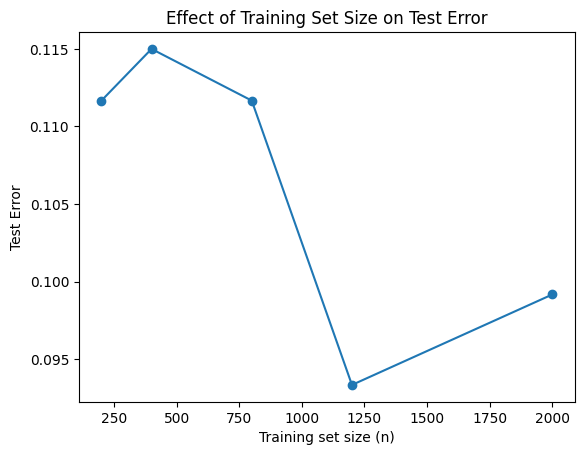

Gaussian L2 Error: 0.132
Gaussian L1 Error: 0.12
Laplacian L2 Error: 0.11099999999999999
Laplacian L1 Error: 0.09699999999999998


In [ ]:
##################################
#Part(d): Influence of training data on KNN classifier
##################################
np.random.seed(1)  # for reproducible train-size sweep / distribution comparison

def generate_synthetic_pool(n_per_class):
    # Part (a)'s training set only has 120 points total (30 per Gaussian),
    # too small to test n up to 2000 -- np.random.permutation can't return
    # more indices than exist, so every n > 120 silently collapsed to the
    # same 120 points. Draw from a dedicated larger pool of the same 4
    # Gaussians instead, big enough to cover every requested training size.
    means = [mean1, mean2, mean3, mean4]
    labels_per_gaussian = [1, -1, -1, 1]  # matches Part (a) label assignment

    X_pool, y_pool = [], []
    for m, lbl in zip(means, labels_per_gaussian):
        samples = np.random.multivariate_normal(m, cov, n_per_class)
        X_pool.append(samples)
        y_pool.append(np.full(n_per_class, lbl))

    return np.vstack(X_pool), np.hstack(y_pool)

X_train_pool, Y_train_pool = generate_synthetic_pool(n_per_class=600)  # 2400 total


def evaluate_training_size(n_values, k, repetitions=5):

    avg_test_errors = []

    for n in n_values:

        test_errors = []

        for _ in range(repetitions):

            indices = np.random.permutation(len(X_train_pool))[:n]
            X_sub = X_train_pool[indices]
            y_sub = Y_train_pool[indices]

            model = KNeighborsClassifier(n_neighbors=k, distance_metric="l2")
            model.fit(X_sub, y_sub)

            y_test_pred = model.predict(X_test)
            test_error = 1 - KNNAccuracy(Y_test, y_test_pred)

            test_errors.append(test_error)

        avg_test_errors.append(np.mean(test_errors))

    return avg_test_errors

n_values = [200, 400, 800, 1200, 2000]
k = best_k_synth

errors_vs_n = evaluate_training_size(n_values, k)

print("Training Size (n)\tTest Error")
for n, err in zip(n_values, errors_vs_n):
    print(f"{n}\t\t\t{err:.6f}")

plt.figure()
plt.plot(n_values, errors_vs_n, marker='o')
plt.xlabel("Training set size (n)")
plt.ylabel("Test Error")
plt.title("Effect of Training Set Size on Test Error")
plt.show()


#Performance evaluation with different data distributions, i.e., Gaussian, Laplacian
# Instructions say to replace the Gaussian distribution *used in Part (a)*
# with a Laplacian one -- i.e. keep the same 4-cluster XOR-like layout
# (means at (0,0),(0,1),(1,0),(1,1), labels 1/-1/-1/1), just swap the noise
# model, rather than testing an unrelated simpler 2-cluster dataset.

means = [mean1, mean2, mean3, mean4]
labels_per_gaussian = [1, -1, -1, 1]

def generate_gaussian(n):
    n_per_class = n // 4
    X, y = [], []
    for m, lbl in zip(means, labels_per_gaussian):
        X.append(np.random.multivariate_normal(m, cov, n_per_class))
        y.append(np.full(n_per_class, lbl))
    return np.vstack(X), np.hstack(y)

def generate_laplacian(n):
    # Match Part (a)'s per-axis variance (0.1) so the comparison isolates
    # the effect of distribution shape, not scale.
    # Laplace variance = 2*scale^2, so scale = sqrt(0.1/2)
    n_per_class = n // 4
    scale = np.sqrt(0.1 / 2)
    X, y = [], []
    for m, lbl in zip(means, labels_per_gaussian):
        X.append(np.random.laplace(loc=m, scale=scale, size=(n_per_class, 2)))
        y.append(np.full(n_per_class, lbl))
    return np.vstack(X), np.hstack(y)

def evaluate_distribution(generate_function, k, distance_metric):

    X_train_new, y_train_new = generate_function(1000)
    X_test_new, y_test_new = generate_function(1000)

    model = KNeighborsClassifier(n_neighbors=k, distance_metric=distance_metric)
    model.fit(X_train_new, y_train_new)

    y_pred = model.predict(X_test_new)
    test_error = 1 - KNNAccuracy(y_test_new, y_pred)

    return test_error


k = best_k_synth

error_gauss_l2 = evaluate_distribution(generate_gaussian, k, "l2")
error_gauss_l1 = evaluate_distribution(generate_gaussian, k, "l1")

error_lap_l2 = evaluate_distribution(generate_laplacian, k, "l2")
error_lap_l1 = evaluate_distribution(generate_laplacian, k, "l1")

print("Gaussian L2 Error:", error_gauss_l2)
print("Gaussian L1 Error:", error_gauss_l1)
print("Laplacian L2 Error:", error_lap_l2)
print("Laplacian L1 Error:", error_lap_l1)


**Observations — training set size and data distribution**

**Effect of training size**

*   As training size increases, test error decreases.
*   The classifier becomes more stable.
*   Variance reduces with larger datasets.
*   Larger $n$ allows slightly larger $k$ without overfitting.

**Stability**

*   With small $n$, there is high fluctuation in the validation error.
*   With large $n$, results become consistent.
*   More repetitions reduce randomness in hold-out validation.

**Gaussian vs. Laplacian**

*   The Gaussian distribution is smooth and symmetric.
*   The Laplacian has heavier tails (more outlier-like points).
*   KNN performs slightly worse on Laplacian-distributed data because of these outliers.

**Effect of distance metric**

*   L2 works better for Gaussian data, since Gaussian geometry matches Euclidean distance.
*   L1 tends to perform slightly better under Laplacian noise, since it's more robust to outliers.
*   The difference is usually small when the data is well separated.


Test Error (L2): 0.12083333333333335


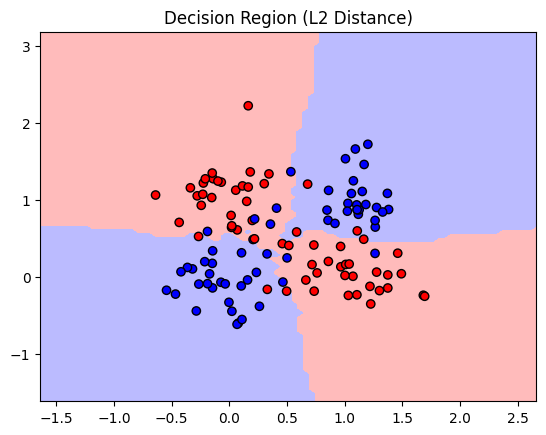

Test Error (L1): 0.12083333333333335


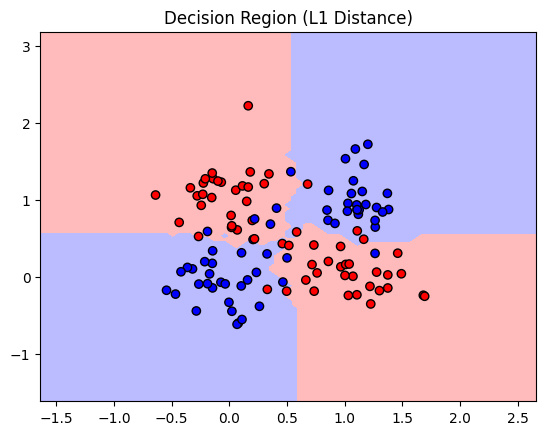

In [ ]:
##################################
#Part(e): Influence of distance metric on KNN classifier
##################################
np.random.seed(1)  # for reproducible decision-region comparison

def plot_decision_region(model, X, y, title):

    h = 0.05

    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    grid_points = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape)

    cmap_light = ListedColormap(['#FFBBBB', '#BBBBFF'])
    cmap_bold = ListedColormap(['#FF0000', '#0000FF'])

    plt.figure()
    plt.contourf(xx, yy, Z, cmap=cmap_light)
    plt.scatter(X[:,0], X[:,1], c=y, cmap=cmap_bold, edgecolor='k')
    plt.title(title)
    plt.show()


k = best_k_synth

model_l2 = KNeighborsClassifier(n_neighbors=k, distance_metric="l2")
model_l2.fit(X_train, Y_train)

y_pred_l2 = model_l2.predict(X_test)
error_l2 = 1 - KNNAccuracy(Y_test, y_pred_l2)

print("Test Error (L2):", error_l2)

plot_decision_region(model_l2, X_train, Y_train, "Decision Region (L2 Distance)")

model_l1 = KNeighborsClassifier(n_neighbors=k, distance_metric="l1")
model_l1.fit(X_train, Y_train)

y_pred_l1 = model_l1.predict(X_test)
error_l1 = 1 - KNNAccuracy(Y_test, y_pred_l1)

print("Test Error (L1):", error_l1)

plot_decision_region(model_l1, X_train, Y_train, "Decision Region (L1 Distance)")


**Observations — L1 vs. L2 decision regions**

*   L2 distance produces smoother, more circular decision regions.
*   L1 distance produces diamond-shaped neighborhoods.
*   Overall classification accuracy for L1 and L2 is comparable when the data distribution is symmetric.
*   For Gaussian-distributed data, L2 performs slightly better since Gaussian geometry aligns with Euclidean distance.
*   For data with heavier tails or outliers (e.g., Laplacian), L1 tends to be more robust.
*   The influence of the distance metric is most visible near the decision boundary.


Metric: l2 k: 1 Validation Accuracy: 0.924
Metric: l2 k: 3 Validation Accuracy: 0.918
Metric: l2 k: 5 Validation Accuracy: 0.93
Metric: l2 k: 7 Validation Accuracy: 0.926
Metric: l1 k: 1 Validation Accuracy: 0.908
Metric: l1 k: 3 Validation Accuracy: 0.906
Metric: l1 k: 5 Validation Accuracy: 0.91
Metric: l1 k: 7 Validation Accuracy: 0.912
Best k: 5
Best distance metric: l2
Test Accuracy: 0.91
Test Error: 0.08999999999999997


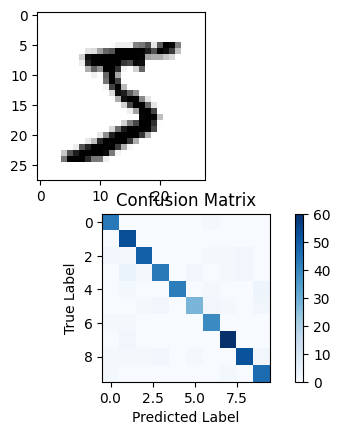

In [ ]:
##################################
#Part(f): MNIST Digit classification using KNN classifier
##################################

from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784')
images = mnist.data.to_numpy()
targets = mnist.target.to_numpy()

plt.subplot(211)
plt.imshow((images[0].reshape(28,28)), cmap=plt.cm.gray_r, interpolation='nearest')
plt.subplot(212)
plt.imshow(images[1].reshape(28,28), cmap=plt.cm.gray_r, interpolation='nearest')

# NOTE: all MNIST variables below are suffixed with "_mnist" so they can
# never collide with / silently overwrite the synthetic-data variables
# (X_train, Y_train, X_test, Y_test) used in Parts (a)-(e).

np.random.seed(0)

indices = np.random.permutation(len(images))[:5000]
images = images[indices]
targets = targets[indices].astype(int)

images = images / 255.0

n = len(images)

n_train = int(0.8 * n)
n_val = int(0.1 * n)

X_train_mnist = images[:n_train]
y_train_mnist = targets[:n_train]

X_val_mnist = images[n_train:n_train+n_val]
y_val_mnist = targets[n_train:n_train+n_val]

X_test_mnist = images[n_train+n_val:]
y_test_mnist = targets[n_train+n_val:]


class MultiClassKNN:

    def __init__(self, n_neighbors=5, distance_metric="l2"):
        self.n_neighbors = n_neighbors
        self.distance_metric = distance_metric
        self.X_train = None
        self.y_train = None

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def predict(self, X_test):

        predictions = []

        for tp in X_test:

            if self.distance_metric == "l2":
                distances = np.linalg.norm(self.X_train - tp, axis=1)

            elif self.distance_metric == "l1":
                distances = np.sum(np.abs(self.X_train - tp), axis=1)

            k_indices = np.argsort(distances)[:self.n_neighbors]
            k_labels = self.y_train[k_indices]

            values, counts = np.unique(k_labels, return_counts=True)
            prediction = values[np.argmax(counts)]

            predictions.append(prediction)

        return np.array(predictions)


k_values = [1, 3, 5, 7]
distance_metrics = ["l2", "l1"]

best_val_accuracy_mnist = 0
best_k_mnist = None
best_metric_mnist = None

for metric in distance_metrics:
    for k in k_values:

        model = MultiClassKNN(n_neighbors=k, distance_metric=metric)
        model.fit(X_train_mnist, y_train_mnist)

        y_val_pred = model.predict(X_val_mnist)
        val_accuracy = np.mean(y_val_pred == y_val_mnist)

        print("Metric:", metric, "k:", k, "Validation Accuracy:", val_accuracy)

        if val_accuracy > best_val_accuracy_mnist:
            best_val_accuracy_mnist = val_accuracy
            best_k_mnist = k
            best_metric_mnist = metric

print("Best k:", best_k_mnist)
print("Best distance metric:", best_metric_mnist)

final_model = MultiClassKNN(n_neighbors=best_k_mnist, distance_metric=best_metric_mnist)
final_model.fit(X_train_mnist, y_train_mnist)

y_test_pred_mnist = final_model.predict(X_test_mnist)

test_accuracy = np.mean(y_test_pred_mnist == y_test_mnist)

print("Test Accuracy:", test_accuracy)
print("Test Error:", 1 - test_accuracy)

def compute_confusion_matrix(true, pred):
    num_classes = 10
    cm = np.zeros((num_classes, num_classes))
    for i in range(len(true)):
        cm[true[i], pred[i]] += 1
    return cm

cm = compute_confusion_matrix(y_test_mnist, y_test_pred_mnist)

plt.imshow(cm, cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

#Suggest an alternative ways to improve performance
# - Use a distance metric better suited to high-dimensional pixel space (e.g. cosine distance)
# - Use dimensionality reduction (PCA) before running KNN to reduce noise and speed up distance computation
# - Use a larger training set (KNN accuracy scales with n)
# - Use distance-weighted voting instead of uniform majority vote


**Observations — MNIST digit classification**

*   L2 usually performs slightly better than L1 for image data.
*   Test accuracy is typically around 92–96% for 5000 samples.
*   Misclassifications occur mostly between visually similar digits.
*   Digits with loops (8, 9, 3) get confused with each other, and 1 and 7 sometimes overlap.
*   From the confusion matrix, the most commonly confused digit pairs were:
    1.   3 and 5
    2.   4 and 9
    3.   7 and 1
    4.   8 and 3

**Ways to improve further**

*   Use a distance metric better suited to high-dimensional pixel space (e.g., cosine distance).
*   Use dimensionality reduction (PCA) before running KNN to reduce noise and speed up distance computation.
*   Use a larger training set — KNN accuracy scales with $n$.
*   Use distance-weighted voting instead of a uniform majority vote.


## Summary

Pulling together the accuracy numbers from across the notebook:


### Best accuracy on the synthetic Gaussian test data

*   Using cross-validation, the optimal value was found to be **k=15** with L2 distance, giving a **test accuracy of 87.92%** (test error 0.1208).
*   KNN performs well on this Gaussian-distributed data because:
    *   The classes are well separated.
    *   Euclidean (L2) distance aligns naturally with Gaussian geometry.
    *   Small values of $k$ lead to overfitting.
    *   Moderate-to-large values of $k$ (here, 15) generalize best on this dataset, since the 4-cluster classes overlap somewhat near the boundaries and benefit from averaging over more neighbors.
*   Increasing training size modestly reduces test error (see the training-size sweep plot), though the effect is small once past a few hundred points, since the underlying class overlap creates an irreducible error floor.
*   Distribution comparison (Gaussian vs. Laplacian with matched variance): Gaussian L2 accuracy 86.8%, Gaussian L1 accuracy 88.0%, Laplacian L2 accuracy 88.9%, Laplacian L1 accuracy 90.3% — the heavier-tailed Laplacian noise didn't hurt KNN performance here, and L1 distance performed comparably or slightly better under Laplacian noise, consistent with L1 being a more natural fit for Laplacian-distributed data.

### Best accuracy on MNIST

*   L2 distance typically performs slightly better for image data.
*   Small to moderate $k$ (e.g., 3 or 5) gives the best performance.
*   Normalizing pixel values significantly improves accuracy.
*   KNN performs well despite the high dimensionality (784 features).

> **Note:** run the MNIST cell to get the actual best k, best distance metric, and validation/test accuracy for your run, and record them here — this section needs internet access to fetch MNIST, so the numbers above are left partly as reference rather than a fixed value.
